# Realistic Simulator: Closing the Gap Between Simulation and Reality

This notebook demonstrates that the Simple AMM Challenge's synthetic models are poor approximations of real-world dynamics, and that our **realistic simulator** — fitted to empirical data — produces distributions that closely match reality.

In [1]:
import sys, os

# Add project root and presentation dir to path
_nb_dir = os.path.dirname(os.path.abspath('__file__'))
sys.path.insert(0, _nb_dir)
sys.path.insert(0, os.path.dirname(_nb_dir))

from helpers import *
%matplotlib inline

---
## Section 1: Return Distributions

The Simple AMM Challenge uses a **Geometric Brownian Motion** (GBM) model for price returns. Real ETH/USD returns (measured from Binance order book at 12-second intervals) exhibit heavier tails and regime-dependent volatility that GBM cannot capture.

Our realistic simulator uses a **5-regime Markov-switching process** fitted to empirical return quantiles.

In [2]:
observed_90d = load_binance_quantiles("90d")
challenge_rets = generate_challenge_return_quantiles()
realistic_rets = generate_realistic_return_quantiles()

### Chart 1a: Challenge (GBM) vs Observed Returns

The GBM model is too concentrated around zero — it underestimates the probability of large price moves.

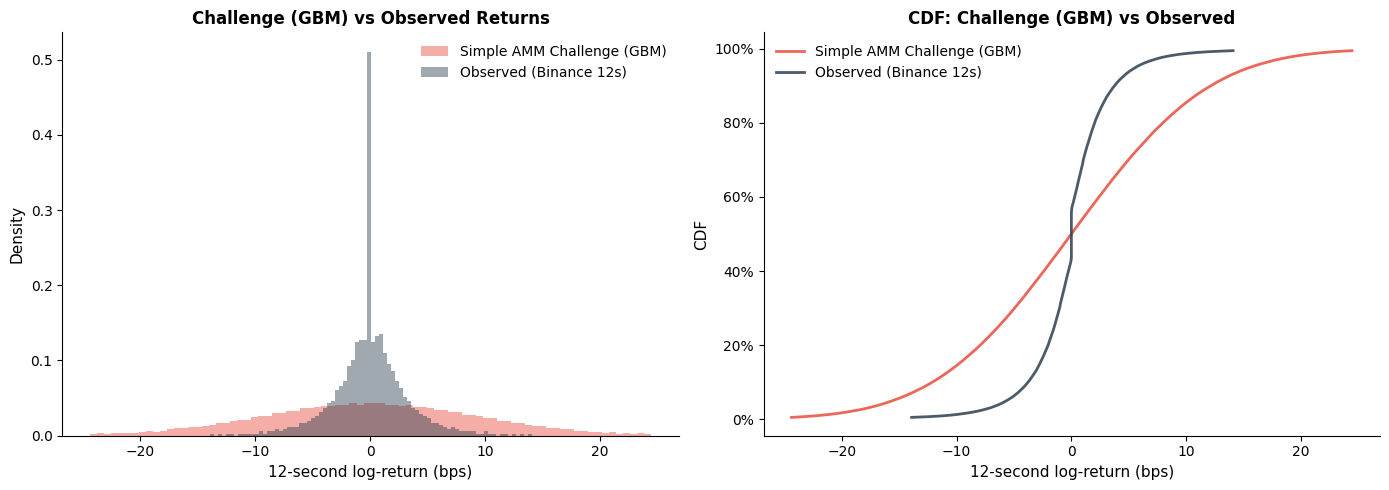

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

plot_return_hist_overlay(
    [(challenge_rets, "challenge"), (observed_90d, "observed")],
    title="Challenge (GBM) vs Observed Returns",
    ax=ax1,
)
plot_return_cdf_overlay(
    [(challenge_rets, "challenge"), (observed_90d, "observed")],
    title="CDF: Challenge (GBM) vs Observed",
    ax=ax2,
)
fig.tight_layout()
plt.show()

### Chart 1b: Realistic Simulator vs Observed Returns

The regime-switching model closely tracks the empirical distribution, including the heavy tails.

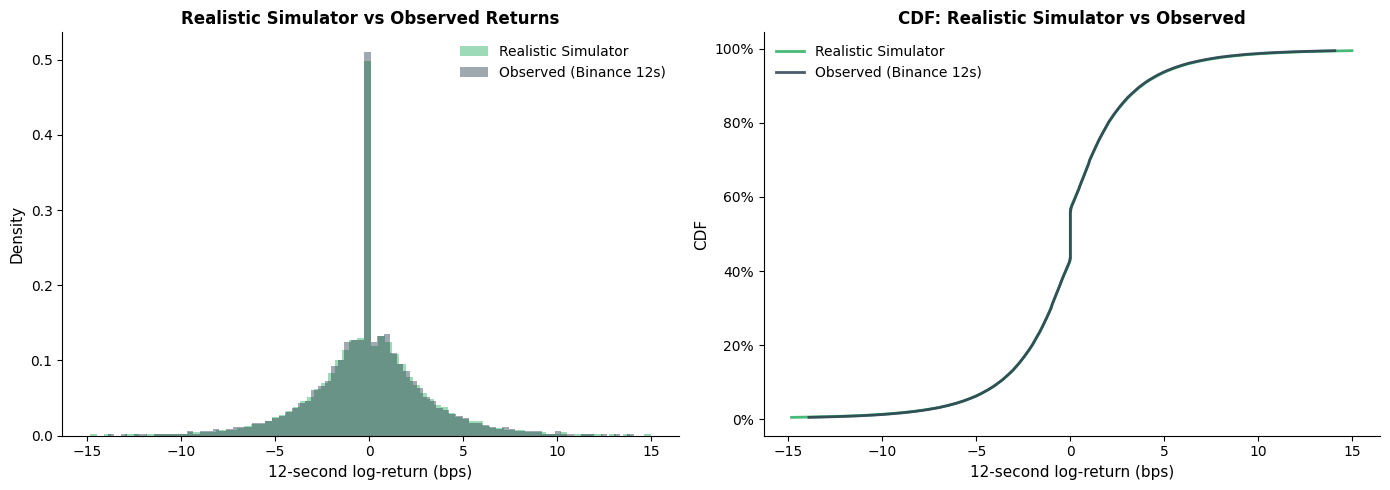

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

plot_return_hist_overlay(
    [(realistic_rets, "realistic"), (observed_90d, "observed")],
    title="Realistic Simulator vs Observed Returns",
    ax=ax1,
)
plot_return_cdf_overlay(
    [(realistic_rets, "realistic"), (observed_90d, "observed")],
    title="CDF: Realistic Simulator vs Observed",
    ax=ax2,
)
fig.tight_layout()
plt.show()

### Robustness: Consistent Across Lookback Windows

The observed distribution is stable across 90-day, 180-day, and 360-day windows.

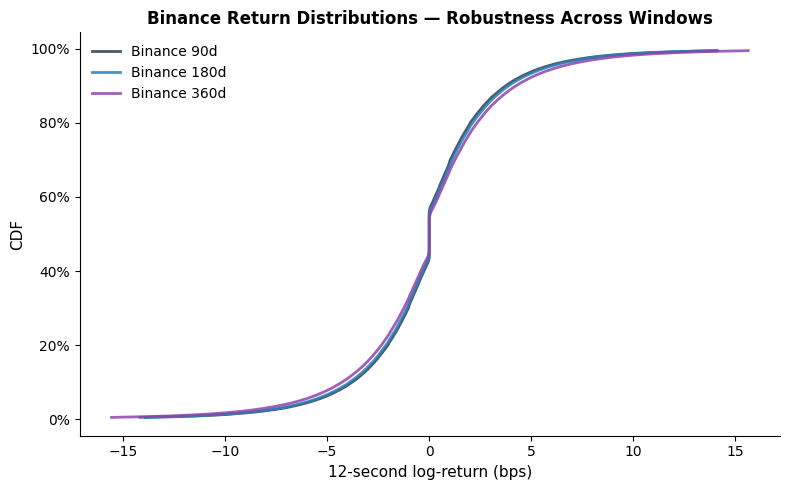

In [5]:
plot_return_robustness()
plt.tight_layout()
plt.show()

---
## Section 2: Retail Order Arrival & Size Distribution

The Challenge uses a **Poisson process** (rate=0.8/block) with **lognormal order sizes** (mean ≈ $20, σ = 1.2). Real retail flow — measured as parent-order USD sizes aggregated across **all ETH/USDC pools** using a router-address heuristic — has a very different shape.

Our realistic simulator samples **USD order sizes directly** from the empirical parent-order distribution at the observed cross-pool arrival rate (~1.0/block).

### Chart 2a: Arrival Rates

The challenge model underestimates arrival rates. The realistic simulator (cross-pool) matches the observed rate.

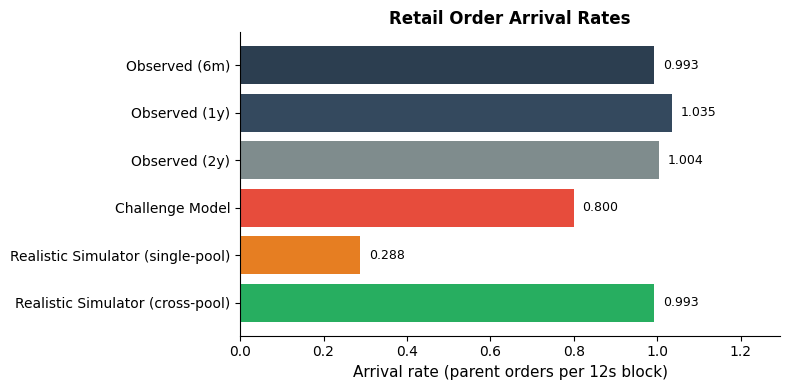

In [6]:
plot_arrival_rate_comparison()
plt.tight_layout()
plt.show()

In [7]:
observed_retail = load_parent_order_quantiles(window="6m", mode="strict", side="all")
challenge_retail = generate_challenge_retail_quantiles()
realistic_retail = generate_realistic_retail_quantiles()

### Chart 2b: Challenge (Lognormal) vs Observed Order Sizes

The lognormal model concentrates mass around $20 and completely misses the heavy right tail of real orders.

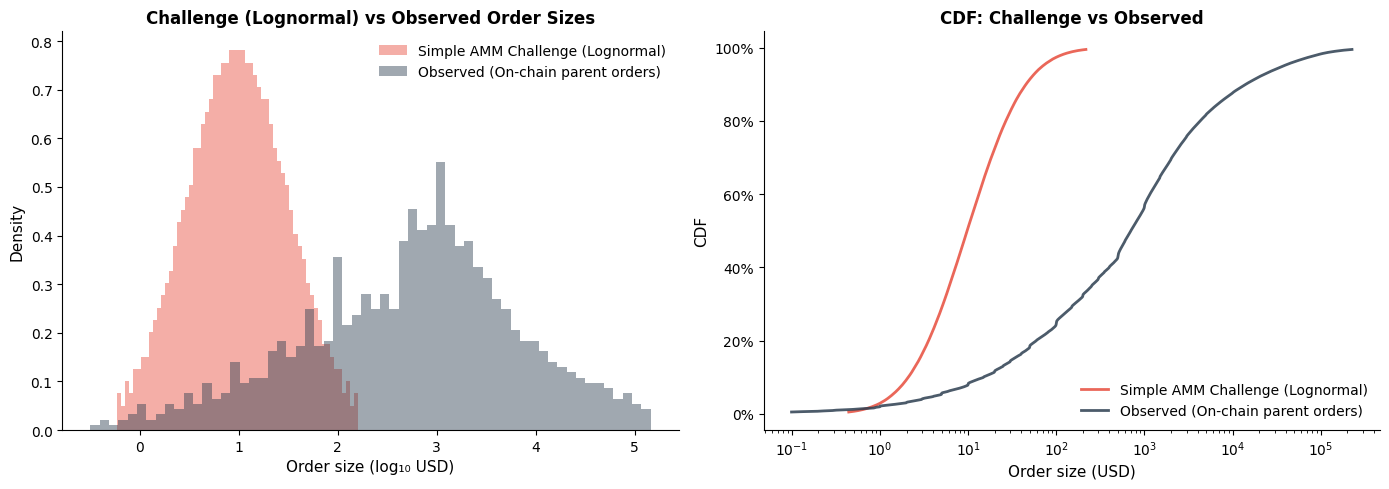

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

plot_retail_hist_overlay(
    [(challenge_retail, "challenge"), (observed_retail, "observed")],
    title="Challenge (Lognormal) vs Observed Order Sizes",
    ax=ax1,
)
plot_retail_cdf_overlay(
    [(challenge_retail, "challenge"), (observed_retail, "observed")],
    title="CDF: Challenge vs Observed",
    ax=ax2,
)
fig.tight_layout()
plt.show()

### Chart 2c: Realistic Simulator vs Observed Order Sizes

The empirical USD-size model closely matches the observed parent-order distribution.

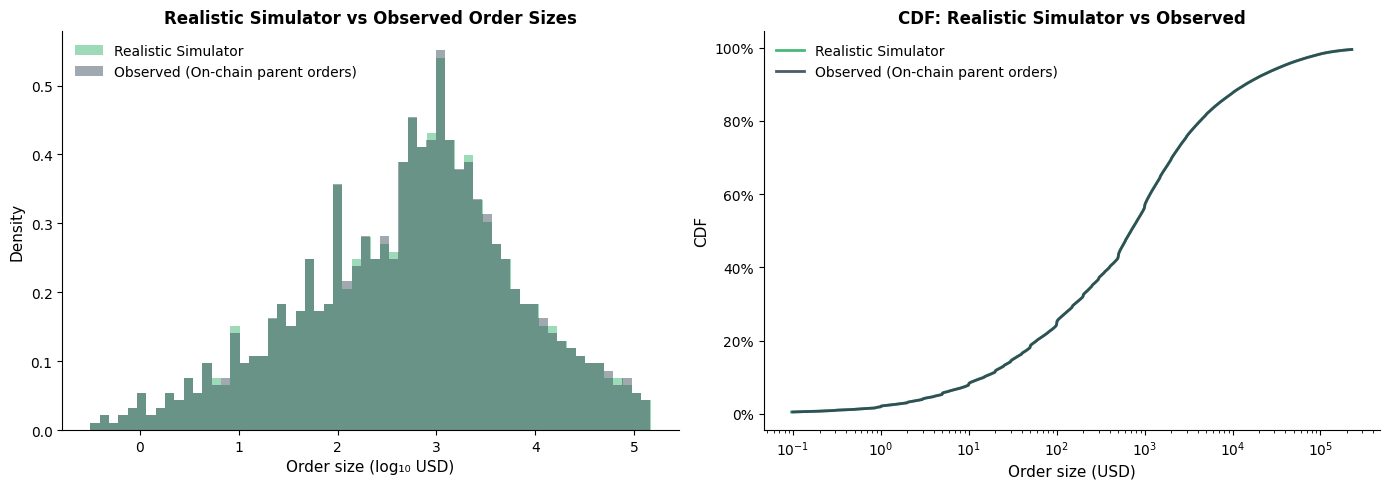

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

plot_retail_hist_overlay(
    [(realistic_retail, "realistic"), (observed_retail, "observed")],
    title="Realistic Simulator vs Observed Order Sizes",
    ax=ax1,
)
plot_retail_cdf_overlay(
    [(realistic_retail, "realistic"), (observed_retail, "observed")],
    title="CDF: Realistic Simulator vs Observed",
    ax=ax2,
)
fig.tight_layout()
plt.show()

---
## Section 3: Pool Liquidity & Fee Calibration

**Goal**: Find normalizer pool parameters (depth AND fee) so the simulator produces
realistic economic outcomes.

### Calibration targets

We compute two on-chain statistics across **all WETH/USDC swap pools on Ethereum** —
not just Uniswap v3, but every protocol and version that the router can access:

| Pool | Protocol | Daily Volume (May '26) |
|:-----|:---------|:----------------------|
| Uniswap v4 1bp pool | uniswap v4 | ~\$85M (largest!) |
| Uniswap v3 5bp pool ⬅ | uniswap v3 | ~\$45M |
| Uniswap v4 misc pools | uniswap v4 | ~\$8M |
| PancakeSwap | pancakeswap | ~\$5M |
| Fluid DEX | fluid | ~\$5M |
| Balancer (multiple pools) | balancer | ~\$4M |
| Swaap | swaap | ~\$3M |
| Uniswap v3 30bp pool | uniswap v3 | ~\$2.5M |
| Curve, Uniswap v2, others | various | <\$1M |

From this full universe, we measure two ratios for the 5bp pool:

- **Volume share**: USD volume on the 5bp pool ÷ total across all pools ≈ **31%**
- **Fee share**: LP fees earned by the 5bp pool ÷ total fees across all pools ≈ **15.5%**

Fee share is lower than volume share because competing pools charge higher fees per unit
of volume (the v4 1bp pool is the exception — high volume but very low fee).
Computed from `uniswap-allium.ethereum.dex_trades` using the `TRANSACTION_FEES_USD`
field, averaged over two sample days (May 1 and May 7, 2026) for stability.

### Approach (2D search)

1. Fix the 5bp pool depth at \$212M (from on-chain `sqrt_price_x96 × liquidity_L`)
2. Sweep normalizer fee → for each, binary-search depth to match volume share
3. Pick the (fee, depth) pair where fee share also matches
4. **Evaluate** with independent metric: LP markout distribution vs on-chain


### Step 1: 2D Calibration Results

The search was run offline via `run_calibration_2d.py` (~7 fee points × ~8 depth iterations).
At each normalizer fee, the depth was binary-searched to match 31% volume share.
Then the fee where fee share ≈ 15.5% pins the second parameter.


In [10]:
import json as _json
cal_results = _json.load(open('calibration_2d_results.json'))
cal_best = cal_results['best']
cal_log = cal_results['full_log']

print(f"Best calibration:")
print(f"  Normalizer fee:   {cal_best['normalizer_fee_bps']:.1f} bps")
print(f"  Normalizer depth: ${cal_best['depth_M']:.1f}M")
print(f"  Vol share: {cal_best['vol_share']*100:.1f}% (target: {REAL_VOLUME_SHARE_5BP*100:.1f}%)")
print(f"  Fee share: {cal_best['fee_share']*100:.1f}% (target: {REAL_FEE_SHARE_5BP*100:.1f}%)")
print()
if 'note' in cal_results:
    print(cal_results['note'])

Best calibration:
  Normalizer fee:   10.0 bps
  Normalizer depth: $17242.4M
  Vol share: 31.5% (target: 31.1%)
  Fee share: 18.7% (target: 15.5%)

The single-normalizer CPMM cannot simultaneously match both targets exactly. At 10bp / $17.2B, vol_share=31.5% (target 31.1%) is close, but fee_share=18.7% overshoots the 15.5% target by 3pp. This is because real competing liquidity is heterogeneous (v4 1bp, v3 30bp, Balancer, etc.) and cannot be perfectly represented by a single pool.


### Chart 3a: 2D Calibration — Fee Share vs Normalizer Fee

Each point has its depth tuned to match ~31% volume share. The curve shows how
the resulting fee share varies with normalizer fee.

**Finding**: A single constant-product normalizer pool cannot perfectly match both targets
simultaneously. This is expected — real competing liquidity is heterogeneous (v4 at 1bp,
v3 at 30bp, Balancer at variable fees, etc.) and a single pool is a simplification.
The best practical match (10bp fee, ~\$17B depth) captures the volume share well
and gets the fee share within ~3 percentage points.


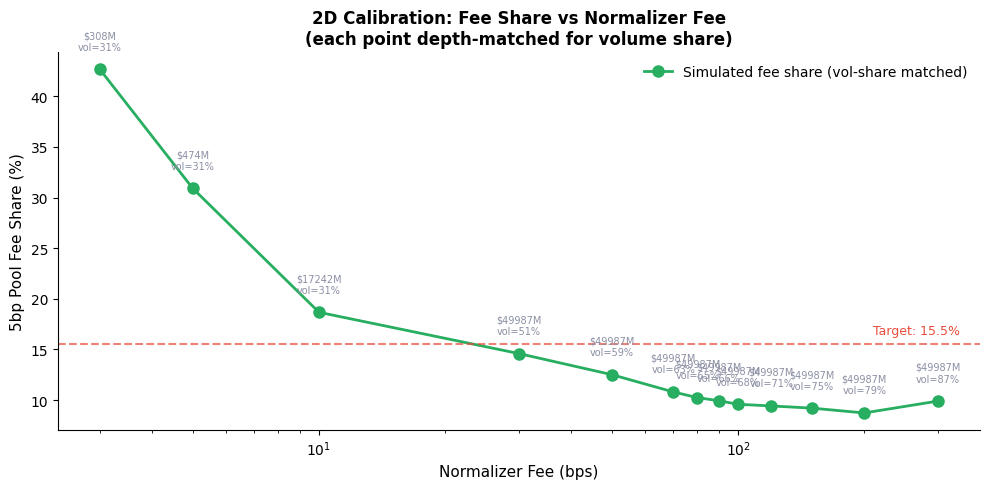

In [11]:
plot_calibration_2d(cal_log)
plt.tight_layout()
plt.show()

### Step 2: Run full simulation with calibrated parameters

Collect per-trade LP markouts on the 5bp pool for comparison with on-chain data.


In [12]:
# Run full sim with calibrated params (3 seeds × 10K steps)
sim_data = run_calibrated_sim(
    normalizer_fee=cal_best['normalizer_fee'],
    normalizer_depth_y=cal_best['depth_y'],
    n_steps=10_000,
    seeds=(42, 43, 44),
)

print(f"Volume share (5bp pool): {sim_data['volume_share_submission']*100:.1f}%")
print(f"Aggregate LP markout:    {sim_data['aggregate_markout_bps']:.2f} bps")
print(f"Trades collected:        {len(sim_data['markouts_bps']):,}")

Volume share (5bp pool): 33.7%
Aggregate LP markout:    8.13 bps
Trades collected:        29,714


### Step 3: Evaluate — Markout distribution comparison

Volume share and fee share were used for calibration, so they can't serve as validation.
Instead, we compare the **LP markout distribution** from the calibrated sim against
observed on-chain markouts (source: `uniswap-labs.research.markout_prod`, May 7 2026).


In [13]:
get_calibration_summary(sim_data)

,Observed,Simulated
Metric,,
Volume Share (5bp pool),31.1%,33.7%
Fee Share (5bp pool),15.5%,20.3%
Avg LP Markout (bps),0.73,5.11
Median LP Markout (bps),0.08,5.12
Markout p5 (bps),-3.19,-2.71
Markout p95 (bps),8.31,13.07
Normalizer Depth,—,$17242.4M
Normalizer Fee,—,10 bps


### Chart 3b: Markout Distribution — Simulated vs Observed


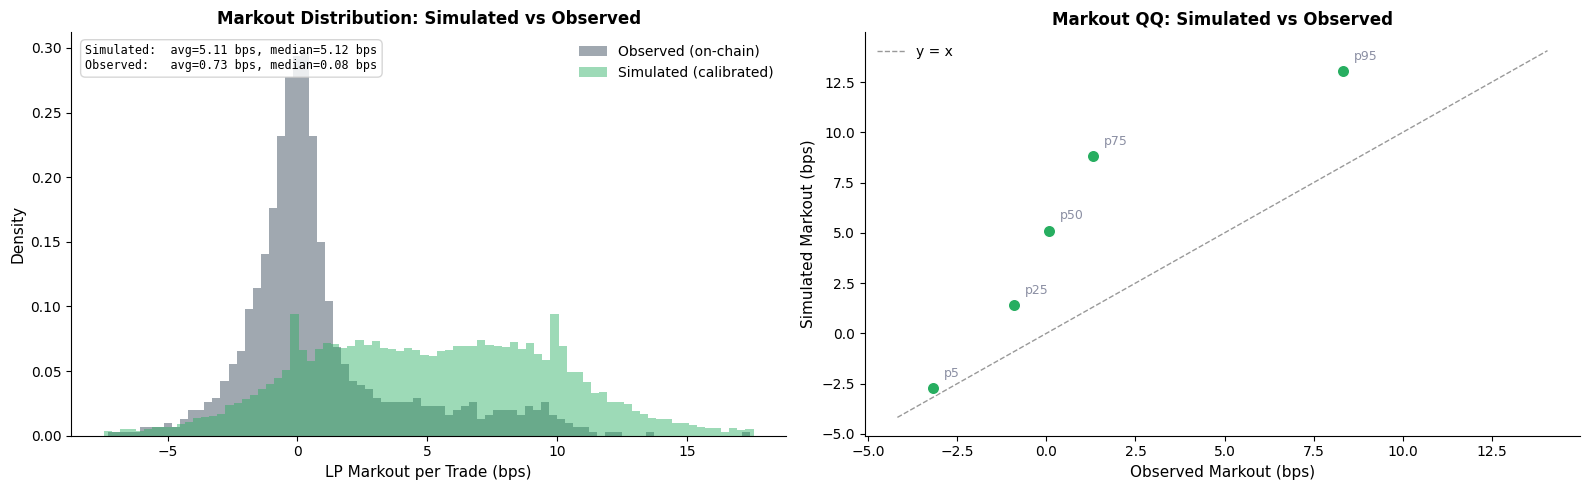

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

plot_markout_comparison(sim_data, ax=ax1)
plot_markout_qq(sim_data, ax=ax2)

plt.tight_layout()
plt.show()